## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
NUTS2_EL = 'θεσσαλιας'

In [4]:
YEAR = 2023
MONTH = 'August'
PERIOD = '1st'

In [5]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_{YEAR}-{MONTH}-{PERIOD}_filled.csv', encoding=enc)
#wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Timeline_2022.csv', encoding=enc)

In [6]:
timeline_file.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week,acc_rainfall_2week
0,αγιας,θεσσαλιας,22.63715,39.66477,2023-08-01,2023,8,2023-08-01,39.662866,22.635299,0.370492,0.034333,-0.427839,-0.034333,0.219168,-0.082988,-0.316662,0.082988,0.079135,0.061730,0.046492,0.061730,NaN,NaN,39.662866,22.635299,14219.000000,13818.000000,14307.062500,13704.263158,14637.352941,13943.333333,14850.466667,14041.625000,2023-07-31,39.650181,22.650104,172.699636,2023-07-25,2023-07-18,2023-07-25,2023-07-18,0.0,0.0
1,αγιας,θεσσαλιας,22.70702,39.75460,2023-08-01,2023,8,2023-08-01,39.752697,22.707165,0.354209,0.291871,-0.246103,-0.291871,0.477410,0.303657,-0.365873,-0.303657,0.142033,0.051151,0.134520,0.051151,NaN,NaN,39.752697,22.707165,14223.600000,13741.846154,14084.133333,13737.714286,14400.923077,13793.692308,14395.000000,13897.142857,2023-07-31,39.750182,22.750104,238.974574,2023-07-25,2023-07-18,2023-07-25,2023-07-18,0.0,0.0
2,αγιας,θεσσαλιας,22.73031,39.79054,2023-08-01,2023,8,2023-08-01,39.788630,22.729622,0.515865,0.083989,-0.498988,-0.083989,0.424160,0.213616,-0.367591,-0.213616,0.098599,0.044688,0.087157,0.044688,NaN,NaN,39.788630,22.729622,14031.307692,13745.444444,13840.846154,13747.428571,14317.428571,13781.400000,14333.600000,13838.888889,2023-07-31,39.750182,22.750104,238.974574,2023-07-25,2023-07-18,2023-07-25,2023-07-18,0.0,0.0
3,αγιας,θεσσαλιας,22.77688,39.66477,2023-08-01,2023,8,2023-08-01,39.662866,22.779030,0.588635,0.235191,-0.518020,-0.235191,0.440729,0.111367,-0.408259,-0.111367,0.083341,0.058407,0.089037,0.058407,NaN,NaN,39.662866,22.779030,14166.800000,13831.857143,14232.187500,13729.571429,14586.642857,13952.500000,14702.571429,14088.285714,2023-07-31,39.650181,22.750104,162.692826,2023-07-25,2023-07-18,2023-07-25,2023-07-18,0.0,0.0
4,αγιας,θεσσαλιας,22.77688,39.70070,2023-08-01,2023,8,2023-08-01,39.698798,22.779030,0.538953,0.143744,-0.491663,-0.143744,0.519645,0.124894,-0.488033,-0.124894,0.054584,0.044943,0.037090,0.044943,NaN,NaN,39.698798,22.779030,14235.545455,13809.769231,14269.294118,13762.076923,14640.357143,13945.142857,14705.153846,14098.000000,2023-07-31,39.750182,22.750104,238.974574,2023-07-25,2023-07-18,2023-07-25,2023-07-18,0.0,0.0


In [7]:
#wnv_file.head()

In [8]:
timeline_file.rename(columns={"region": "nuts2"}, inplace=True)

In [9]:
timeline_file = timeline_file.rename(columns=lambda x: re.sub('_new', '', x))

In [11]:
timeline_file.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [12]:
timeline_file.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αγιας,θεσσαλιας,22.63715,39.66477,2023-08-01,2023,8,0.370492,0.034333,-0.427839,-0.034333,0.219168,-0.082988,-0.316662,0.082988,0.079135,0.061730,0.046492,0.061730,NaN,NaN,14219.000000,13818.000000,14307.062500,13704.263158,14637.352941,13943.333333,14850.466667,14041.625000,172.699636,0.0,0.0
1,αγιας,θεσσαλιας,22.70702,39.75460,2023-08-01,2023,8,0.354209,0.291871,-0.246103,-0.291871,0.477410,0.303657,-0.365873,-0.303657,0.142033,0.051151,0.134520,0.051151,NaN,NaN,14223.600000,13741.846154,14084.133333,13737.714286,14400.923077,13793.692308,14395.000000,13897.142857,238.974574,0.0,0.0
2,αγιας,θεσσαλιας,22.73031,39.79054,2023-08-01,2023,8,0.515865,0.083989,-0.498988,-0.083989,0.424160,0.213616,-0.367591,-0.213616,0.098599,0.044688,0.087157,0.044688,NaN,NaN,14031.307692,13745.444444,13840.846154,13747.428571,14317.428571,13781.400000,14333.600000,13838.888889,238.974574,0.0,0.0
3,αγιας,θεσσαλιας,22.77688,39.66477,2023-08-01,2023,8,0.588635,0.235191,-0.518020,-0.235191,0.440729,0.111367,-0.408259,-0.111367,0.083341,0.058407,0.089037,0.058407,NaN,NaN,14166.800000,13831.857143,14232.187500,13729.571429,14586.642857,13952.500000,14702.571429,14088.285714,162.692826,0.0,0.0
4,αγιας,θεσσαλιας,22.77688,39.70070,2023-08-01,2023,8,0.538953,0.143744,-0.491663,-0.143744,0.519645,0.124894,-0.488033,-0.124894,0.054584,0.044943,0.037090,0.044943,NaN,NaN,14235.545455,13809.769231,14269.294118,13762.076923,14640.357143,13945.142857,14705.153846,14098.000000,238.974574,0.0,0.0


In [13]:
#wnv_file.head(5)

In [14]:
# ## Find if there are lau1 units in the epidemiological file and are not contained in the spatiotemporal file.

# names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
# names_from_shapefile = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
# diff = []

# for element in names_from_wnv_file:
#     if element not in names_from_shapefile:
#         diff.append(element)
        

# print(f"{diff}\n\nLength: {len(diff)}")


In [15]:
#wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('ηρωικης πολεως ναουσας','ναουσας'))

In [16]:
# ## Check again

# names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
# names_from_shapefile = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
# diff = []

# for element in names_from_wnv_file:
#     if element not in names_from_shapefile:
#         diff.append(element)
        

# print(f"{diff}\n\nLength: {len(diff)}")

In [17]:
# merged = timeline_file.merge(wnv_file, how='left', on=['dt_placement', 'lau1', 'nuts2'] )
merged = timeline_file

In [18]:
# merged

In [19]:
# merged = fillna(merged,{'case': 0})
merged['case'] = 0

In [20]:
merged['case'].value_counts()

0    126
Name: case, dtype: int64

In [21]:
grouped = merged.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)

In [22]:
dataset = grouped.mean()

In [23]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case
0,2023-08-01,αγιας,θεσσαλιας,22.750267,39.710970,2023.0,8.0,0.504676,0.184783,-0.455058,-0.184783,0.480495,0.183731,-0.431407,-0.183731,0.083756,0.050454,0.071820,0.050454,NaN,NaN,14158.229570,13810.607919,14132.381348,13770.111663,14483.438175,13900.012383,14528.540407,14007.143707,211.711384,0.0,0.0,0.0
1,2023-08-01,αλμυρου,θεσσαλιας,22.692366,39.136391,2023.0,8.0,0.472622,0.111141,-0.446070,-0.111141,0.456914,0.096210,-0.432481,-0.096210,0.063769,0.058472,0.035170,0.058472,NaN,NaN,14236.213555,13871.070700,14235.830525,13815.772792,14503.039805,14000.498550,14640.452078,14072.106614,314.133211,0.0,0.0,0.0
2,2023-08-01,αλοννησου,θεσσαλιας,24.073790,39.328960,2023.0,8.0,0.405488,0.032937,-0.376530,-0.032937,0.414660,0.039871,-0.375798,-0.039871,0.027351,0.038605,0.015157,0.038605,NaN,NaN,14303.111111,14120.666667,14247.800000,14074.285714,14424.133333,14144.066667,14543.000000,14215.666667,204.246283,0.0,0.0,0.0
3,2023-08-01,αργιθεας,θεσσαλιας,21.430513,39.221380,2023.0,8.0,0.656492,0.350661,-0.534098,-0.350661,0.604800,0.294615,-0.501389,-0.294615,0.046175,0.055259,0.028865,0.055259,NaN,NaN,13984.796537,13767.640659,13972.290278,13581.276389,14264.541026,13850.111111,14318.077381,13868.033333,201.881806,0.0,0.0,0.0
4,2023-08-01,βολου,θεσσαλιας,22.883800,39.351977,2023.0,8.0,0.398398,0.038744,-0.389705,-0.038744,0.375690,0.026398,-0.371939,-0.026398,0.041397,0.037417,0.027065,0.037417,NaN,NaN,14310.624820,13874.456288,14320.436508,13834.927778,14589.631410,13978.820513,14708.583333,14067.142857,208.555492,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20,2023-08-01,τεμπων,θεσσαλιας,22.553160,39.852112,2023.0,8.0,0.501045,0.127962,-0.462019,-0.127962,0.494594,0.117515,-0.453937,-0.117515,0.059609,0.062963,0.034723,0.062963,NaN,NaN,14131.844872,13769.820000,14115.170075,13710.264791,14425.669118,13892.648535,14496.147902,13987.089286,155.597145,0.0,0.0,0.0
21,2023-08-01,τρικκαιων,θεσσαλιας,21.797560,39.635058,2023.0,8.0,0.451681,0.050418,-0.457180,-0.050418,0.435101,0.031466,-0.447723,-0.031466,0.066011,0.060949,0.039491,0.060949,NaN,NaN,14191.183077,13785.802381,14353.424316,13765.126176,14621.389846,13986.928283,14689.561490,14047.238095,296.693971,0.0,0.0,0.0
22,2023-08-01,τυρναβου,θεσσαλιας,22.343000,39.828472,2023.0,8.0,0.479748,0.099030,-0.465198,-0.099030,0.452282,0.092872,-0.426375,-0.092872,0.076410,0.074815,0.074628,0.074815,NaN,NaN,14205.631944,13756.379121,14250.387054,13720.940664,14569.709428,13922.793269,14687.921314,14042.280258,124.964158,0.0,0.0,0.0
23,2023-08-01,φαρκαδονας,θεσσαλιας,22.020557,39.603750,2023.0,8.0,0.364534,-0.015631,-0.398823,0.015631,0.409016,0.033867,-0.424689,-0.033867,0.066191,0.064942,0.037878,0.064942,NaN,NaN,14179.025000,13814.481685,14325.770833,13813.812500,14609.167725,14019.155400,14719.909041,14095.839286,233.073064,0.0,0.0,0.0


In [24]:
dataset = dataset.astype({'case': 'int'})

In [25]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [26]:
dataset['x'] = dataset['x'].apply(lambda x : round(x,5))
dataset['y'] = dataset['y'].apply(lambda x : round(x,5))
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['month'] = dataset['dt_placement'].apply(lambda x : x.month)
dataset['year'] = dataset['dt_placement'].apply(lambda x : x.year)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [27]:
lau1_map = lau1_mapping(dataset, 0, 0)

In [28]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [29]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos
0,2023-08-01,αγιας,θεσσαλιας,22.75027,39.71097,2023,8,0.504676,0.184783,-0.455058,-0.184783,0.480495,0.183731,-0.431407,-0.183731,0.083756,0.050454,0.071820,0.050454,NaN,NaN,14158.229570,13810.607919,14132.381348,13770.111663,14483.438175,13900.012383,14528.540407,14007.143707,211.711384,0.0,0.0,0,1,31,45.76610,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044
1,2023-08-01,αλμυρου,θεσσαλιας,22.69237,39.13639,2023,8,0.472622,0.111141,-0.446070,-0.111141,0.456914,0.096210,-0.432481,-0.096210,0.063769,0.058472,0.035170,0.058472,NaN,NaN,14236.213555,13871.070700,14235.830525,13815.772792,14503.039805,14000.498550,14640.452078,14072.106614,314.133211,0.0,0.0,0,1,31,45.23937,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044
2,2023-08-01,αλοννησου,θεσσαλιας,24.07379,39.32896,2023,8,0.405488,0.032937,-0.376530,-0.032937,0.414660,0.039871,-0.375798,-0.039871,0.027351,0.038605,0.015157,0.038605,NaN,NaN,14303.111111,14120.666667,14247.800000,14074.285714,14424.133333,14144.066667,14543.000000,14215.666667,204.246283,0.0,0.0,0,1,31,46.11198,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044
3,2023-08-01,αργιθεας,θεσσαλιας,21.43051,39.22138,2023,8,0.656492,0.350661,-0.534098,-0.350661,0.604800,0.294615,-0.501389,-0.294615,0.046175,0.055259,0.028865,0.055259,NaN,NaN,13984.796537,13767.640659,13972.290278,13581.276389,14264.541026,13850.111111,14318.077381,13868.033333,201.881806,0.0,0.0,0,1,31,44.69433,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044
4,2023-08-01,βολου,θεσσαλιας,22.88380,39.35198,2023,8,0.398398,0.038744,-0.389705,-0.038744,0.375690,0.026398,-0.371939,-0.026398,0.041397,0.037417,0.027065,0.037417,NaN,NaN,14310.624820,13874.456288,14320.436508,13834.927778,14589.631410,13978.820513,14708.583333,14067.142857,208.555492,0.0,0.0,0,1,31,45.52194,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20,2023-08-01,τεμπων,θεσσαλιας,22.55316,39.85211,2023,8,0.501045,0.127962,-0.462019,-0.127962,0.494594,0.117515,-0.453937,-0.117515,0.059609,0.062963,0.034723,0.062963,NaN,NaN,14131.844872,13769.820000,14115.170075,13710.264791,14425.669118,13892.648535,14496.147902,13987.089286,155.597145,0.0,0.0,0,1,31,45.79122,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044
21,2023-08-01,τρικκαιων,θεσσαλιας,21.79756,39.63506,2023,8,0.451681,0.050418,-0.457180,-0.050418,0.435101,0.031466,-0.447723,-0.031466,0.066011,0.060949,0.039491,0.060949,NaN,NaN,14191.183077,13785.802381,14353.424316,13765.126176,14621.389846,13986.928283,14689.561490,14047.238095,296.693971,0.0,0.0,0,1,31,45.23352,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044
22,2023-08-01,τυρναβου,θεσσαλιας,22.34300,39.82847,2023,8,0.479748,0.099030,-0.465198,-0.099030,0.452282,0.092872,-0.426375,-0.092872,0.076410,0.074815,0.074628,0.074815,NaN,NaN,14205.631944,13756.379121,14250.387054,13720.940664,14569.709428,13922.793269,14687.921314,14042.280258,124.964158,0.0,0.0,0,1,31,45.66746,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044
23,2023-08-01,φαρκαδονας,θεσσαλιας,22.02056,39.60375,2023,8,0.364534,-0.015631,-0.398823,0.015631,0.409016,0.033867,-0.424689,-0.033867,0.066191,0.064942,0.037878,0.064942,NaN,NaN,14179.025000,13814.481685,14325.770833,13813.812500,14609.167725,14019.155400,14719.909041,14095.839286,233.073064,0.0,0.0,0,1,31,45.31404,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044


<AxesSubplot:>

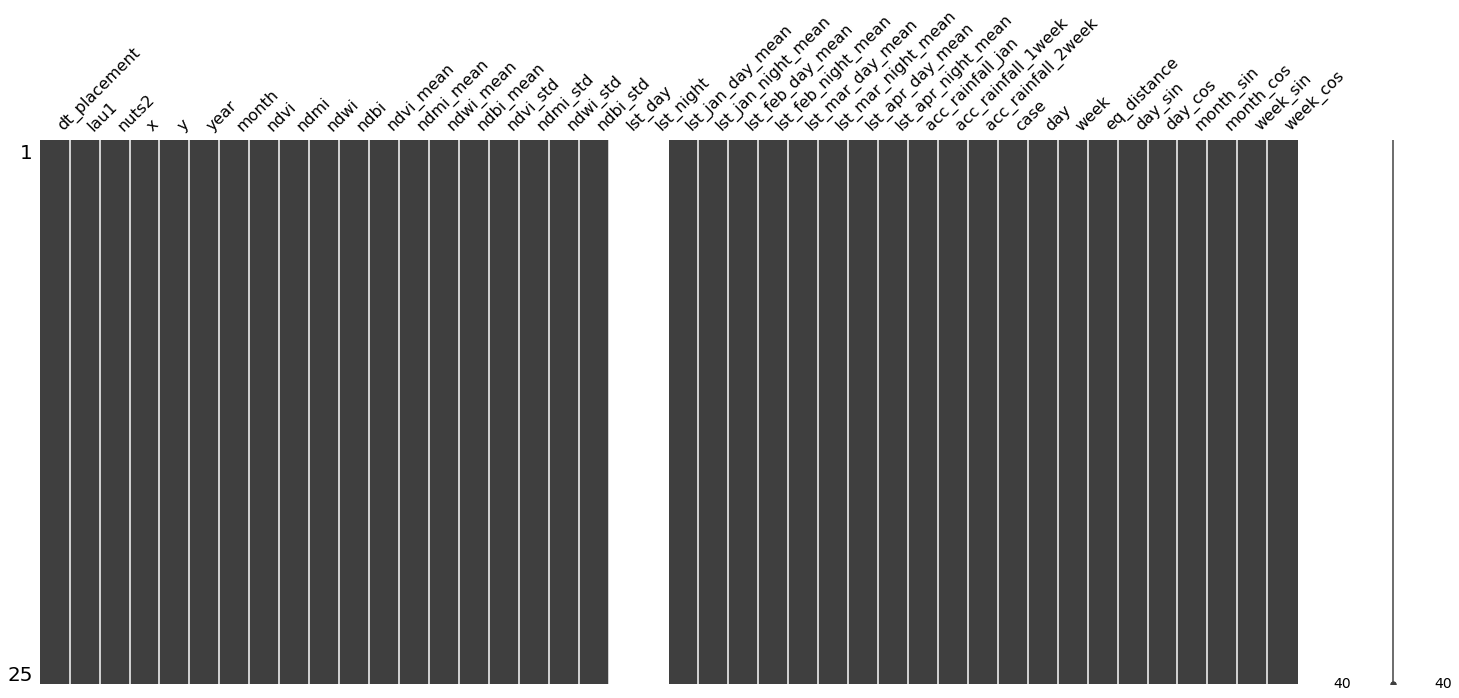

In [30]:
missingno.matrix(dataset)

In [31]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_WEB_Demographics_Processed.csv', encoding = enc)

In [32]:
df_demographics

,lau1,nuts2,nuts3,area,population_density,population
0,αβδηρων,ανατολικης μακεδονιας και θρακης,ξανθης,352.0,54.0,17860.0
1,αγαθονησιου,νοτιου αιγαιου,καλυμνου,14.5,12.8,203.0
2,αγιας,θεσσαλιας,λαρισας,661.8,17.3,10705.0
3,αγιας βαρβαρας,αττικης,δυτικου τομεα αθηνων,2.4,10925.9,26759.0
4,αγιας παρασκευης,αττικης,βορειου τομεα αθηνων,7.9,7557.5,62157.0
...,...,...,...,...,...,...
327,χανιων,κρητης,χανιων,351.3,309.3,110646.0
328,χερσονησου,κρητης,ηρακλειου,272.2,98.2,27229.0
329,χιου,βορειου αιγαιου,χιου,842.3,61.0,50483.0
330,ωραιοκαστρου,κεντρικης μακεδονιας,θεσσαλονικης,217.9,175.8,40114.0


In [33]:
df_demographics_nuts2 = df_demographics.query(f"nuts2 == '{NUTS2_EL}'").copy()

In [34]:
df_demographics_nuts2.drop(columns=['nuts2', 'nuts3'], inplace=True)
df_demographics_nuts2.reset_index(inplace=True, drop=True)

In [35]:
df_demographics_nuts2

,lau1,area,population_density,population
0,αγιας,661.8,17.3,10705.00
1,αλμυρου,905.4,20.6,16004.00
2,αλοννησου,129.6,21.2,3153.00
3,αργιθεας,372.9,9.3,3515.00
4,βολου,385.6,374.6,138865.00
...,...,...,...,...
20,τεμπων,576.7,23.8,11.99
21,τρικκαιων,607.6,133.9,78508.00
22,τυρναβου,525.3,47.7,22252.00
23,φαρκαδονος,368.7,36.3,11348.00


In [36]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

['καλαμπακας', 'λαρισαιων', 'ρηγα φερραιου', 'φαρκαδονας']

Length: 4


In [37]:
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('μετεωρων','καλαμπακας'))
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('λαρισας','λαρισαιων'))
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('ρηγα φεραιου','ρηγα φερραιου'))
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('φαρκαδονος','φαρκαδονας'))


In [38]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [39]:
dataset = pd.merge(dataset, df_demographics_nuts2,  how='left', on=['lau1'])

<AxesSubplot:>

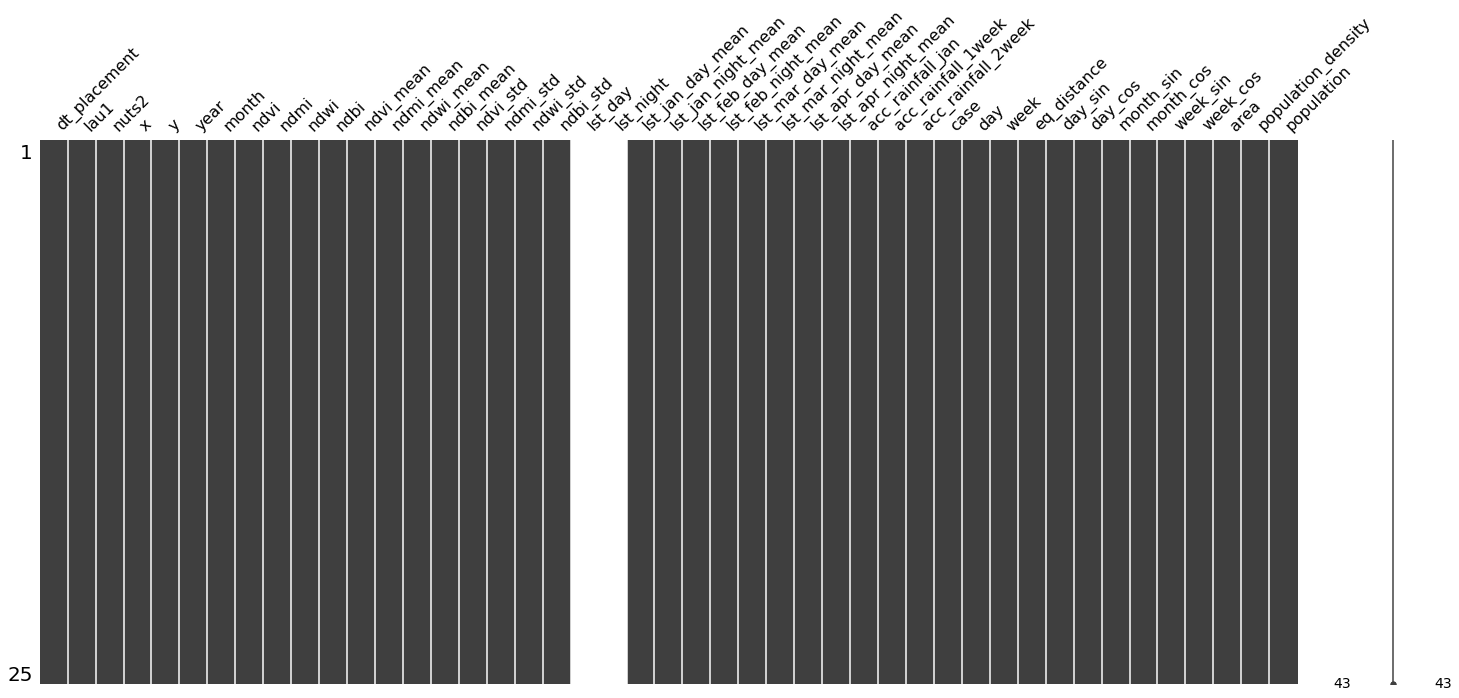

In [40]:
missingno.matrix(dataset)

In [41]:
missing = describe_dataframe(dataset)

In [42]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population_density,population
0,2023-08-01,αγιας,θεσσαλιας,22.75027,39.71097,2023,8,0.504676,0.184783,-0.455058,-0.184783,0.480495,0.183731,-0.431407,-0.183731,0.083756,0.050454,0.071820,0.050454,NaN,NaN,14158.229570,13810.607919,14132.381348,13770.111663,14483.438175,13900.012383,14528.540407,14007.143707,211.711384,0.0,0.0,0,1,31,45.76610,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,661.8,17.3,10705.00
1,2023-08-01,αλμυρου,θεσσαλιας,22.69237,39.13639,2023,8,0.472622,0.111141,-0.446070,-0.111141,0.456914,0.096210,-0.432481,-0.096210,0.063769,0.058472,0.035170,0.058472,NaN,NaN,14236.213555,13871.070700,14235.830525,13815.772792,14503.039805,14000.498550,14640.452078,14072.106614,314.133211,0.0,0.0,0,1,31,45.23937,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,905.4,20.6,16004.00
2,2023-08-01,αλοννησου,θεσσαλιας,24.07379,39.32896,2023,8,0.405488,0.032937,-0.376530,-0.032937,0.414660,0.039871,-0.375798,-0.039871,0.027351,0.038605,0.015157,0.038605,NaN,NaN,14303.111111,14120.666667,14247.800000,14074.285714,14424.133333,14144.066667,14543.000000,14215.666667,204.246283,0.0,0.0,0,1,31,46.11198,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,129.6,21.2,3153.00
3,2023-08-01,αργιθεας,θεσσαλιας,21.43051,39.22138,2023,8,0.656492,0.350661,-0.534098,-0.350661,0.604800,0.294615,-0.501389,-0.294615,0.046175,0.055259,0.028865,0.055259,NaN,NaN,13984.796537,13767.640659,13972.290278,13581.276389,14264.541026,13850.111111,14318.077381,13868.033333,201.881806,0.0,0.0,0,1,31,44.69433,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,372.9,9.3,3515.00
4,2023-08-01,βολου,θεσσαλιας,22.88380,39.35198,2023,8,0.398398,0.038744,-0.389705,-0.038744,0.375690,0.026398,-0.371939,-0.026398,0.041397,0.037417,0.027065,0.037417,NaN,NaN,14310.624820,13874.456288,14320.436508,13834.927778,14589.631410,13978.820513,14708.583333,14067.142857,208.555492,0.0,0.0,0,1,31,45.52194,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,385.6,374.6,138865.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20,2023-08-01,τεμπων,θεσσαλιας,22.55316,39.85211,2023,8,0.501045,0.127962,-0.462019,-0.127962,0.494594,0.117515,-0.453937,-0.117515,0.059609,0.062963,0.034723,0.062963,NaN,NaN,14131.844872,13769.820000,14115.170075,13710.264791,14425.669118,13892.648535,14496.147902,13987.089286,155.597145,0.0,0.0,0,1,31,45.79122,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,576.7,23.8,11.99
21,2023-08-01,τρικκαιων,θεσσαλιας,21.79756,39.63506,2023,8,0.451681,0.050418,-0.457180,-0.050418,0.435101,0.031466,-0.447723,-0.031466,0.066011,0.060949,0.039491,0.060949,NaN,NaN,14191.183077,13785.802381,14353.424316,13765.126176,14621.389846,13986.928283,14689.561490,14047.238095,296.693971,0.0,0.0,0,1,31,45.23352,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,607.6,133.9,78508.00
22,2023-08-01,τυρναβου,θεσσαλιας,22.34300,39.82847,2023,8,0.479748,0.099030,-0.465198,-0.099030,0.452282,0.092872,-0.426375,-0.092872,0.076410,0.074815,0.074628,0.074815,NaN,NaN,14205.631944,13756.379121,14250.387054,13720.940664,14569.709428,13922.793269,14687.921314,14042.280258,124.964158,0.0,0.0,0,1,31,45.66746,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,525.3,47.7,22252.00
23,2023-08-01,φαρκαδονας,θεσσαλιας,22.02056,39.60375,2023,8,0.364534,-0.015631,-0.398823,0.015631,0.409016,0.033867,-0.424689,-0.033867,0.066191,0.064942,0.037878,0.064942,NaN,NaN,14179.025000,13814.481685,14325.770833,13813.812500,14609.167725,14019.

In [43]:
df_mosquitoes = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_{YEAR}-{MONTH}-{PERIOD}.csv', encoding = enc)
df_mosquitoes

,x,y,dt_placement,mosq_pred
0,22.750267,39.710970,2023-08-01,49
1,22.692366,39.136391,2023-08-01,41
2,24.073790,39.328960,2023-08-01,38
3,21.430513,39.221380,2023-08-01,54
4,22.883800,39.351977,2023-08-01,100
...,...,...,...,...
20,22.553160,39.852112,2023-08-01,143
21,21.797560,39.635058,2023-08-01,193
22,22.343000,39.828472,2023-08-01,168
23,22.020557,39.603750,2023-08-01,204


In [44]:
df_mosquitoes['dt_placement'] = pd.to_datetime(dataset['dt_placement'])
df_mosquitoes['x'] = df_mosquitoes['x'].apply(lambda x : round(x,5))
df_mosquitoes['y'] = df_mosquitoes['y'].apply(lambda x : round(x,5))

In [45]:
distances, indicies = calculate_nearest_topological(dataset, df_mosquitoes)

In [46]:
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.0
Max distance: 0.0008571819480130482


In [47]:
df_mosq = pd.DataFrame(columns=df_mosquitoes.columns)

In [48]:
for index in indicies:
    df_mosq = df_mosq.append(df_mosquitoes.iloc[[index]])

df_mosq.drop(columns=['x', 'y', 'dt_placement'], inplace = True)
df_mosq.reset_index(drop=True, inplace=True)

In [49]:
dataset = pd.concat([dataset, df_mosq], axis=1, join = 'outer')

In [50]:
dataset.head()

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population_density,population,mosq_pred
0,2023-08-01,αγιας,θεσσαλιας,22.75027,39.71097,2023,8,0.504676,0.184783,-0.455058,-0.184783,0.480495,0.183731,-0.431407,-0.183731,0.083756,0.050454,0.071820,0.050454,NaN,NaN,14158.229570,13810.607919,14132.381348,13770.111663,14483.438175,13900.012383,14528.540407,14007.143707,211.711384,0.0,0.0,0,1,31,45.76610,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,661.8,17.3,10705.0,49
1,2023-08-01,αλμυρου,θεσσαλιας,22.69237,39.13639,2023,8,0.472622,0.111141,-0.446070,-0.111141,0.456914,0.096210,-0.432481,-0.096210,0.063769,0.058472,0.035170,0.058472,NaN,NaN,14236.213555,13871.070700,14235.830525,13815.772792,14503.039805,14000.498550,14640.452078,14072.106614,314.133211,0.0,0.0,0,1,31,45.23937,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,905.4,20.6,16004.0,41
2,2023-08-01,αλοννησου,θεσσαλιας,24.07379,39.32896,2023,8,0.405488,0.032937,-0.376530,-0.032937,0.414660,0.039871,-0.375798,-0.039871,0.027351,0.038605,0.015157,0.038605,NaN,NaN,14303.111111,14120.666667,14247.800000,14074.285714,14424.133333,14144.066667,14543.000000,14215.666667,204.246283,0.0,0.0,0,1,31,46.11198,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,129.6,21.2,3153.0,38
3,2023-08-01,αργιθεας,θεσσαλιας,21.43051,39.22138,2023,8,0.656492,0.350661,-0.534098,-0.350661,0.604800,0.294615,-0.501389,-0.294615,0.046175,0.055259,0.028865,0.055259,NaN,NaN,13984.796537,13767.640659,13972.290278,13581.276389,14264.541026,13850.111111,14318.077381,13868.033333,201.881806,0.0,0.0,0,1,31,44.69433,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,372.9,9.3,3515.0,54
4,2023-08-01,βολου,θεσσαλιας,22.88380,39.35198,2023,8,0.398398,0.038744,-0.389705,-0.038744,0.375690,0.026398,-0.371939,-0.026398,0.041397,0.037417,0.027065,0.037417,NaN,NaN,14310.624820,13874.456288,14320.436508,13834.927778,14589.631410,13978.820513,14708.583333,14067.142857,208.555492,0.0,0.0,0,1,31,45.52194,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,385.6,374.6,138865.0,100


<AxesSubplot:>

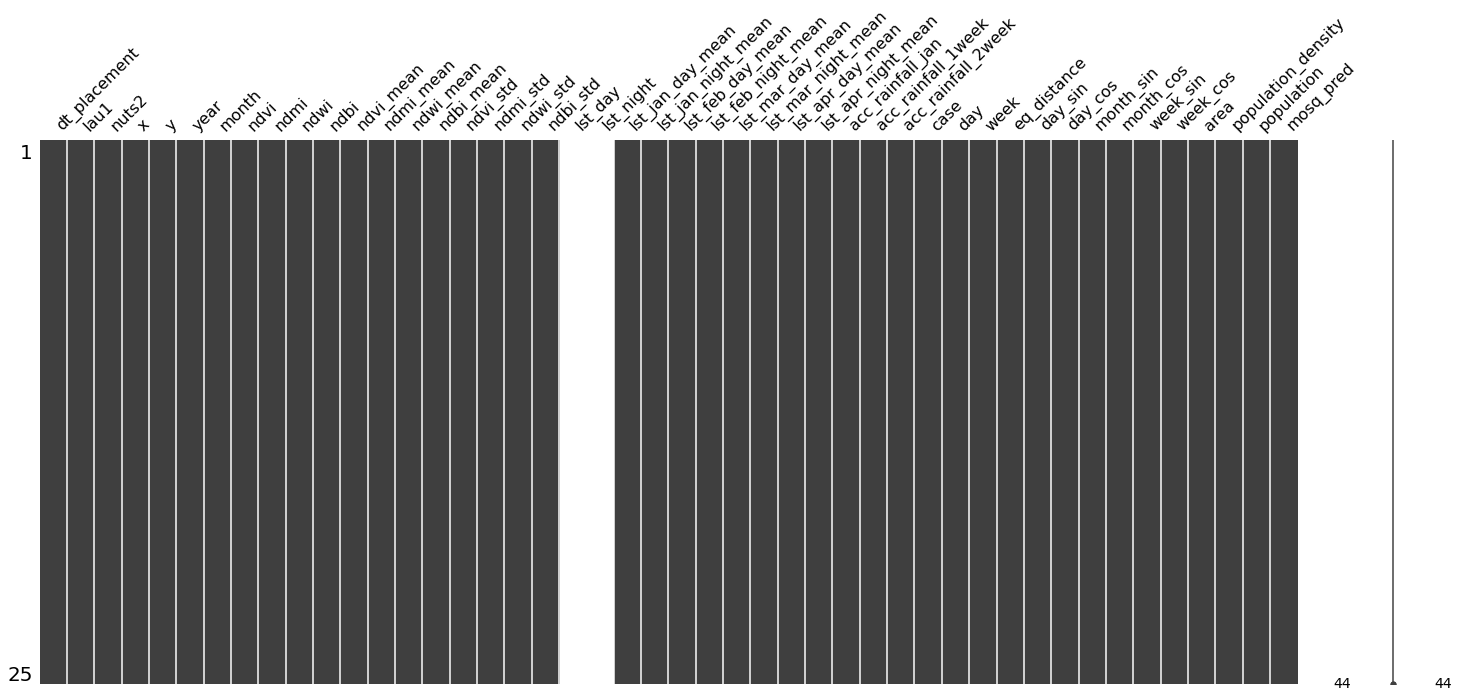

In [51]:
missingno.matrix(dataset)

In [52]:
dataset.reset_index(inplace=True, drop=True)

In [53]:
dataset = calculate_mosq_previous(dataset)

In [54]:
dataset = convert_temperature(dataset)

<AxesSubplot:>

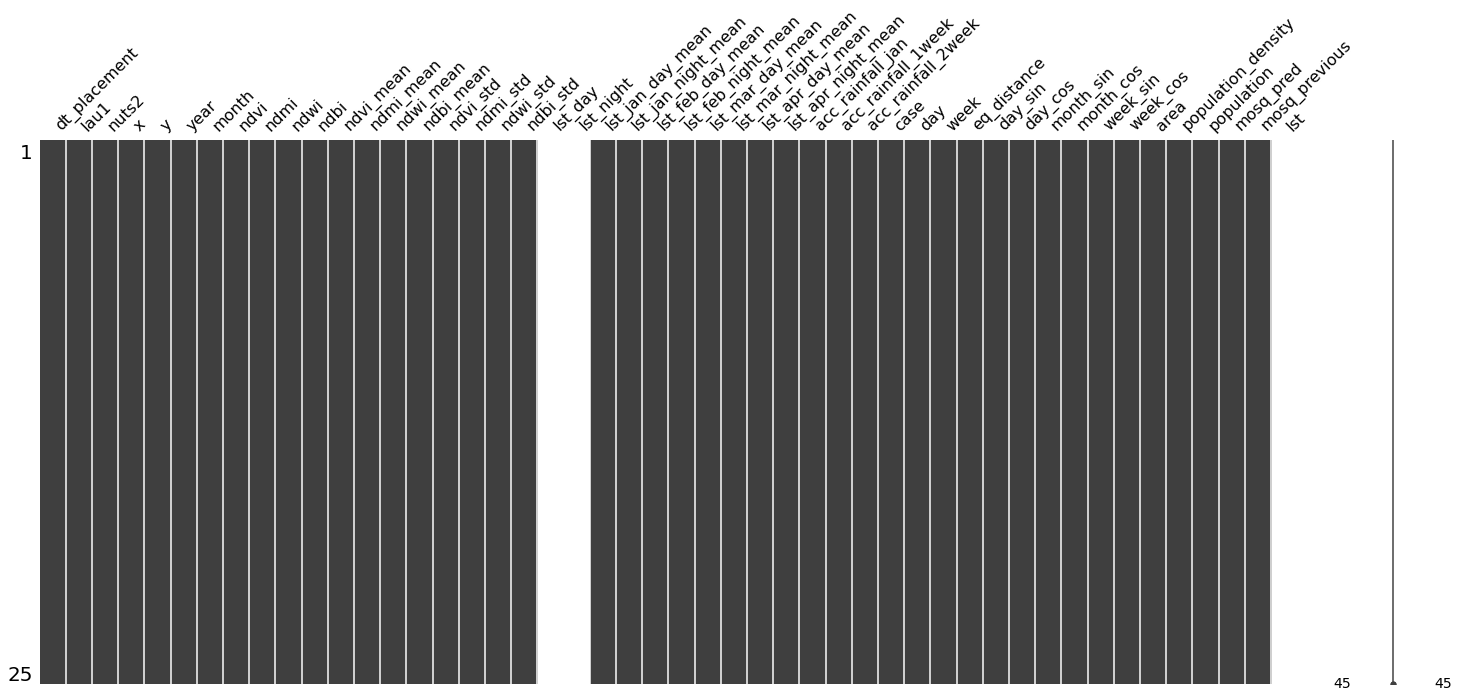

In [55]:
missingno.matrix(dataset)

In [56]:
dataset['case'].value_counts()

0    25
Name: case, dtype: int64

In [57]:
dataset = dataset.astype({'mosq_pred' : 'int', 'mosq_previous' : 'int'})

In [58]:
dataset = convert_multiple_cases(dataset)

In [59]:
dataset['case'].value_counts()

0    25
Name: case, dtype: int64

In [60]:
cols = dataset.columns

In [61]:
cols

Index(['dt_placement', 'lau1', 'nuts2', 'x', 'y', 'year', 'month', 'ndvi',
       'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_jan', 'acc_rainfall_1week', 'acc_rainfall_2week', 'case',
       'day', 'week', 'eq_distance', 'day_sin', 'day_cos', 'month_sin',
       'month_cos', 'week_sin', 'week_cos', 'area', 'population_density',
       'population', 'mosq_pred', 'mosq_previous', 'lst'],
      dtype='object')

In [62]:
len(cols)

48

In [63]:
# check columns

In [64]:
final_columns = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 
                 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 
                 'month_cos', 'week_sin', 'week_cos', 'area', 'population',
                 'population_density', 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 
                 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 
                 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
                 'lst_day', 'lst_night','lst_jan_day_mean', 'lst_jan_night_mean', 
                 'lst_feb_day_mean','lst_feb_night_mean', 'lst_mar_day_mean', 
                 'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
                 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
                 'mosq_pred', 'mosq_previous', 'case']

In [65]:
len(final_columns)

48

In [66]:
dataset_final = dataset[final_columns].copy()

In [67]:
dataset_final

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case
0,22.75027,39.71097,2023-08-01,θεσσαλιας,αγιας,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,661.8,10705.00,17.3,45.76610,0.504676,0.184783,-0.455058,-0.184783,0.480495,0.183731,-0.431407,-0.183731,0.083756,0.050454,0.071820,0.050454,NaN,NaN,NaN,10.014591,3.062158,9.497627,2.252233,16.518764,4.850248,17.420808,6.992874,0.0,0.0,211.711384,49,0,0
1,22.69237,39.13639,2023-08-01,θεσσαλιας,αλμυρου,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,905.4,16004.00,20.6,45.23937,0.472622,0.111141,-0.446070,-0.111141,0.456914,0.096210,-0.432481,-0.096210,0.063769,0.058472,0.035170,0.058472,NaN,NaN,NaN,11.574271,4.271414,11.566611,3.165456,16.910796,6.859971,19.659042,8.292132,0.0,0.0,314.133211,41,0,0
2,24.07379,39.32896,2023-08-01,θεσσαλιας,αλοννησου,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,129.6,3153.00,21.2,46.11198,0.405488,0.032937,-0.376530,-0.032937,0.414660,0.039871,-0.375798,-0.039871,0.027351,0.038605,0.015157,0.038605,NaN,NaN,NaN,12.912222,9.263333,11.806000,8.335714,15.332667,9.731333,17.710000,11.163333,0.0,0.0,204.246283,38,0,0
3,21.43051,39.22138,2023-08-01,θεσσαλιας,αργιθεας,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,372.9,3515.00,9.3,44.69433,0.656492,0.350661,-0.534098,-0.350661,0.604800,0.294615,-0.501389,-0.294615,0.046175,0.055259,0.028865,0.055259,NaN,NaN,NaN,6.545931,2.202813,6.295806,-1.524472,12.140821,3.852222,13.211548,4.210667,0.0,0.0,201.881806,54,0,0
4,22.88380,39.35198,2023-08-01,θεσσαλιας,βολου,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,385.6,138865.00,374.6,45.52194,0.398398,0.038744,-0.389705,-0.038744,0.375690,0.026398,-0.371939,-0.026398,0.041397,0.037417,0.027065,0.037417,NaN,NaN,NaN,13.062496,4.339126,13.258730,3.548556,18.642628,6.426410,21.021667,8.192857,0.0,0.0,208.555492,100,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20,22.55316,39.85211,2023-08-01,θεσσαλιας,τεμπων,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,576.7,11.99,23.8,45.79122,0.501045,0.127962,-0.462019,-0.127962,0.494594,0.117515,-0.453937,-0.117515,0.059609,0.062963,0.034723,0.062963,NaN,NaN,NaN,9.486897,2.246400,9.153402,1.055296,15.363382,4.702971,16.772958,6.591786,0.0,0.0,155.597145,143,0,0
21,21.79756,39.63506,2023-08-01,θεσσαλιας,τρικκαιων,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,607.6,78508.00,133.9,45.23352,0.451681,0.050418,-0.457180,-0.050418,0.435101,0.031466,-0.447723,-0.031466,0.066011,0.060949,0.039491,0.060949,NaN,NaN,NaN,10.673662,2.566048,13.918486,2.152524,19.277797,6.588566,20.641230,7.794762,0.0,0.0,296.693971,193,0,0
22,22.34300,39.82847,2023-08-01,θεσσαλιας,τυρναβου,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,525.3,22252.00,47.7,45.66746,0.479748,0.099030,-0.465198,-0.099030,0.452282,0.092872,-0.426375,-0.092872,0.076410,0.074815,0.074628,0.074815,NaN,NaN,NaN,10.962639,1.977582,11.857741,1.268813,18.244189,5.305865,20.608426,7.695605,0.0,0.0,124.964158,168,0,0
23,22.02056,39.60375,2023-08-01,θεσσαλιας,φαρκαδονας,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,368.7,11348.00,36.3,45.31404,0.364534,-0.015631,-0.398823,0.015631,0.409016,0.033867,-0.424689,-0.033867,0.066191,0.064942,0.037878,0.064942,NaN,NaN,NaN,10.430500,3.139634,13.365417,3.126250,19.033354,7.233108,21.248181,8.766786,0.0,0.0,233.0730

In [68]:
dataset_final.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_{YEAR}-{MONTH}-{PERIOD}.csv", encoding = enc, index = False)